# Homework 6  - Logistic Regression without using any libraries. 
 
Student Name: Kyle Castillo

Student UT EID: kmc5794

---

Partner Name: Andre Sae

Partner UT EID: as226576

---

Date Created: 10/6/2025

Date Last Modified:

---

Totoal Points 20. 



In [2]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [384]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task 1 - (4 points)
We want to use logistic regerssion to predict if a patient will have heart problems or not. The column "Target" in our datasets includes data about heart disease. If the patient had heart disease, the patient's "Target" value equals 1. Otherwise, "Target" equals 0.

Prepare your data set for predicting heart disease ("Target" column) by using 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 

Split your data into 80% traning data and 20% test data ***without*** using any libraries other than the ones imported above. You must do it manually.

* Do a maximum of **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher/lower. 
* **Visualize your error/costs over the iterations with a plot**.
* No need to add an y-intercept in this task. 

(**4 points** - 3 points for code, 1 point for cost visualization)

In [385]:
# selecting features
features = heart_df[["Age", "Sex", "Chol"]]
# features = heart_df[["Age", "Chol"]]
labels = (heart_df["Target"] == "Yes").astype(int)
features["Age"] = features["Age"] - features["Age"].mean()
features["Chol"] = features["Chol"]  - features["Chol"].mean()
features["Sex"] = (features["Sex"] * 2) - 1


# train/test split
split = .8

train = np.arange(0, round(features.shape[0] * split) + 1)
test = np.arange(train[-1] + 1, features.shape[0])

train_x = features.loc[train]
train_y = labels.loc[train]

test_x = features.loc[test]
test_y = labels.loc[test]

/tmp/ipykernel_1781596/1110213187.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Age"] = features["Age"] - features["Age"].mean()
/tmp/ipykernel_1781596/1110213187.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Chol"] = features["Chol"]  - features["Chol"].mean()
/tmp/ipykernel_1781596/1110213187.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

In [ ]:
def sigmoid(w, x):
    z = x.dot(w)
    return (1   /    (1 + (np.e ** -z)) ).reshape(-1,1)

def cost(w, x, y):
    # to avoid 0's in log
    a = np.clip(sigmoid(w,x), 1e-12, 1 - 1e-12)
    
    cost_calc = (-1/len(y)) * sum((y *   np.log(a)) + ((1 - y) * (np.log(1-a))))
    return cost_calc

def grad_descent(w,x,y,alpha=.1):
    # learning_rule
    a = sigmoid(w,x)

    gradient = (x.T.dot(a - y)) / len(y)


    # descending to new w
    new_w = w.reshape((alpha * gradient).shape[0], -1) - alpha * gradient

    return new_w


In [391]:
w = np.zeros(train_x.shape[1]).reshape(3,)
# w[1] = 0.80
# w = np.zeros(train_x.shape[1]).reshape(2,)
x = train_x.to_numpy().reshape(-1,3)
# x = train_x.to_numpy().reshape(-1,2)
y = train_y.to_numpy().reshape(-1,1)

cost_hist = np.array([])

iterations = 100
alpha = .0001

for i in range(iterations):
    cost_val = cost(w,x,y)
    cost_hist = np.append(cost_hist,cost_val)
    w = grad_descent(w,x,y,alpha)
    # print(w)

    print(f"new cost: {cost_val}")

new cost: [0.69314718]
new cost: [0.69236486]
new cost: [0.69167263]
new cost: [0.69105859]
new cost: [0.69051239]
new cost: [0.69002503]
new cost: [0.68958873]
new cost: [0.68919673]
new cost: [0.68884318]
new cost: [0.68852304]
new cost: [0.68823192]
new cost: [0.68796603]
new cost: [0.6877221]
new cost: [0.68749729]
new cost: [0.68728914]
new cost: [0.68709552]
new cost: [0.68691459]
new cost: [0.68674473]
new cost: [0.68658457]
new cost: [0.6864329]
new cost: [0.68628866]
new cost: [0.68615095]
new cost: [0.68601897]
new cost: [0.68589204]
new cost: [0.68576955]
new cost: [0.68565098]
new cost: [0.68553588]
new cost: [0.68542384]
new cost: [0.68531452]
new cost: [0.68520763]
new cost: [0.68510289]
new cost: [0.68500007]
new cost: [0.68489897]
new cost: [0.68479943]
new cost: [0.68470127]
new cost: [0.68460438]
new cost: [0.68450862]
new cost: [0.6844139]
new cost: [0.68432013]
new cost: [0.68422722]
new cost: [0.68413512]
new cost: [0.68404375]
new cost: [0.68395306]
new cost: [0.6

In [392]:
y_pred = np.matmul(w.T, x.T)
y_pred = np.transpose(y_pred)
y_pred = np.exp(y_pred) / (1 + np.exp(y_pred))
y_pred[y_pred < 0.5] = 0
y_pred[y_pred >= 0.5] = 1


print("f1 score: " + str(f1_score(y, y_pred)))
print("accuracy score: " + str(accuracy_score(y, y_pred)))
print("recall score: " + str(recall_score(y, y_pred)))
print("precisions score: " + str(precision_score(y, y_pred)))
print("weights: " + str(w))

f1 score: 0.6
accuracy score: 0.6213991769547325
recall score: 0.6448598130841121
precisions score: 0.5609756097560976
weights: [[0.00937899]
 [0.00117113]
 [0.00351133]]


In [393]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

model = LogisticRegression(fit_intercept=False, penalty=None)

model.fit(train_x, train_y)

train_y_pred = model.predict(train_x)

cost_function_value = log_loss(y, model.predict_proba(train_x))

print("f1 score: " + str(f1_score(train_y, train_y_pred)))
print("accuracy score: " + str(accuracy_score(train_y, train_y_pred)))
print("recall score: " + str(recall_score(train_y, train_y_pred)))
print("precisions score: " + str(precision_score(train_y, train_y_pred)))
print("log-loss score: " + str(cost_function_value))

print("weights: " + str(model.coef_))

f1 score: 0.6513409961685823
accuracy score: 0.6255144032921811
recall score: 0.794392523364486
precisions score: 0.551948051948052
log-loss score: 0.6249647063924526
weights: [[0.06576599 0.57167365 0.00310283]]


Text(0.5, 1.0, 'iterations vs cost')

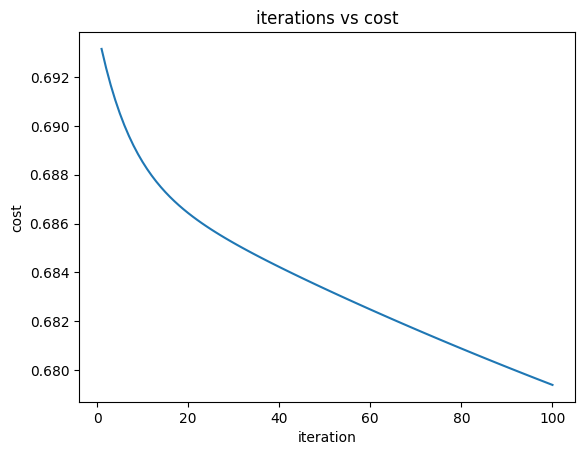

In [394]:
x = np.arange(1,101)
y = cost_hist


plt.plot(x,y)

plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("iterations vs cost")



# Task 2 - (4 points)

Cacluate the Accuracy, Precision, Recall and F1 score of your logistic regression implementaion on the testing set. 
Print the results. 

You may use equations shown in lecture/slides/examples.

Calcuate the accuracy, precision, recall and F1 score of your logistic regression implementaion on the testing set. 
Print the results. (**4 points**)


In [ ]:
# Add your code Here! 



# Task 3 - (4 points)

Add a y-intercept and repeat the above tasks. Do you see any differences after adding the y-intercept?

(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)

In [ ]:
# Add your code Here! 

# Task 4 - Implement the Bold Driver   - (4 points)

Implement the bold driver into your gradient descent implementation, which lets us have a dynamic learning rate. Visualize the costs and print the accuracy/etc. metrics as before. Do not use a y-intercept this time.

Add a stop condition that stop the GD when the cost is not changing more than 0.001 between iterations. 
Describe the results. Did you stop earlier than 100 iterations?
(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)



In [395]:
# selecting features
features = heart_df[["Age", "Sex", "Chol"]]
# features = heart_df[["Age", "Chol"]]
labels = (heart_df["Target"] == "Yes").astype(int)
features["Age"] = features["Age"] - features["Age"].mean()
features["Chol"] = features["Chol"]  - features["Chol"].mean()
features["Sex"] = (features["Sex"] * 2) - 1


# train/test split
split = .8

train = np.arange(0, round(features.shape[0] * split) + 1)
test = np.arange(train[-1] + 1, features.shape[0])

train_x = features.loc[train]
train_y = labels.loc[train]

test_x = features.loc[test]
test_y = labels.loc[test]

/tmp/ipykernel_1781596/1110213187.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Age"] = features["Age"] - features["Age"].mean()
/tmp/ipykernel_1781596/1110213187.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Chol"] = features["Chol"]  - features["Chol"].mean()
/tmp/ipykernel_1781596/1110213187.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

In [396]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

w = np.zeros(train_x.shape[1]).reshape(3,)
x = train_x.to_numpy().reshape(-1,3)
y = train_y.to_numpy().reshape(-1,1)

cost_hist = np.array([])
prev_weight = None

iterations = 100
alpha = .0001
final_iterations = iterations

for i in range(iterations):
    cost_val = cost(w,x,y)
    w = grad_descent(w,x,y,alpha)

    if i != 0: 
        prev_cost_val = cost_hist[len(cost_hist) - 1]
        if prev_cost_val > cost_val: 
            alpha -= alpha * 0.025
        elif prev_cost_val + (10 ** -10) < cost_val:
            w = prev_weight
            alpha = alpha * 0.5
            
        if abs(cost_val - cost_hist[len(cost_hist) - 2]) < 0.001:
            final_iterations = i
            cost_hist = np.append(cost_hist,cost_val)
            print("Stopped at iteration # " + str(final_iterations))
            break
        

    cost_hist = np.append(cost_hist,cost_val)
    prev_weight = w 

    print(f"new cost: {cost_val}")

    
y_pred = np.matmul(w.T, x.T)
y_pred = np.transpose(y_pred)
y_pred = np.exp(y_pred) / (1 + np.exp(y_pred))
y_pred[y_pred < 0.5] = 0
y_pred[y_pred >= 0.5] = 1

print("cost history: " + str(cost_hist))
print("f1 score: " + str(f1_score(y, y_pred)))
print("accuracy score: " + str(accuracy_score(y, y_pred)))
print("recall score: " + str(recall_score(y, y_pred)))
print("precisions score: " + str(precision_score(y, y_pred)))



new cost: [0.69314718]
Stopped at iteration # 1
cost history: [0.69314718 0.69236486]
f1 score: 0.5877192982456141
accuracy score: 0.6131687242798354
recall score: 0.6261682242990654
precisions score: 0.5537190082644629


Text(0.5, 1.0, 'iterations vs cost')

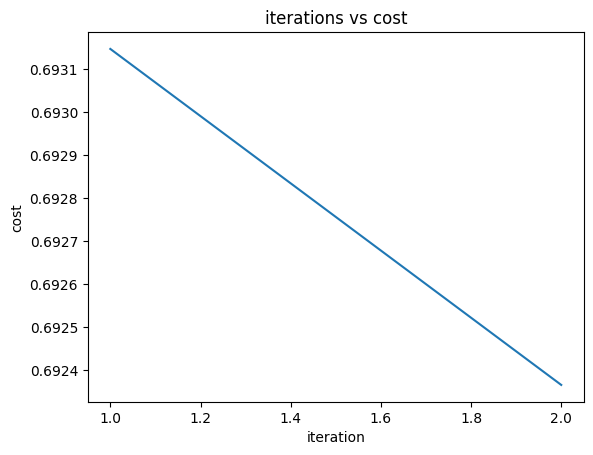

In [397]:
x = np.arange(1,len(cost_hist)+1)
y = cost_hist

plt.plot(x,y)

plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("iterations vs cost")

Bold driver + gradient descent should converge faster than gradient descent. It stopped much earlier than 100 iterations. But the trade of is that the accuracy and F1 score is not as good.

# Task 5 - Implement the L2 norm regularization.  - (4 points)



Modify your Cost and gradient to implement the l2 norm regularization. Repeat the steps taken in prior tasks and describe your result.

 * Use a y-intercept.
 * Do a maximum of 100 iterations as before and report your accuracy, precision, recall and F1 score.
 * Optional: You can stop earlier, if the cost is not changing more than 0.001 between iterations.
 * Optional: You can use the bold driver, if you want. But a bold driver is not required to perform L2 norm regularizaiton.

(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)

In [ ]:
# Add your code Here! 

def grad_descent_reg(w,x,y,alpha=.1,l=0.1):
    # learning_rule
    a = sigmoid(w,x)
    
    
    gradient = (x.T.dot(a - y)) / len(y)
    reg = l * w


    # descending to new w
    new_w = w.reshape((alpha * gradient).shape[0], -1) - alpha * ( gradient + reg )
    
    return new_w

In [ ]:
w = np.zeros(train_x.shape[1]).reshape(3,)
x = train_x.to_numpy().reshape(-1,3)
y = train_y.to_numpy().reshape(-1,1)


w = np.array([0, *w])
x = np.column_stack((np.ones(shape=(len(x))), x))

cost_hist = np.array([])

iterations = 100
alpha = .0001

for i in range(iterations):
    cost_val = cost(w,x,y)
    cost_hist = np.append(cost_hist,cost_val)
    w = grad_descent(w,x,y,alpha)

    print(f"new cost: {cost_val}")

[0. 0. 0. 0.]
[[  1.  63.   1. 233.]
 [  1.  67.   1. 286.]
 [  1.  67.   1. 229.]
 [  1.  37.   1. 250.]
 [  1.  41.   0. 204.]
 [  1.  56.   1. 236.]
 [  1.  62.   0. 268.]
 [  1.  57.   0. 354.]
 [  1.  63.   1. 254.]
 [  1.  53.   1. 203.]
 [  1.  57.   1. 192.]
 [  1.  56.   0. 294.]
 [  1.  56.   1. 256.]
 [  1.  44.   1. 263.]
 [  1.  52.   1. 199.]
 [  1.  57.   1. 168.]
 [  1.  48.   1. 229.]
 [  1.  54.   1. 239.]
 [  1.  48.   0. 275.]
 [  1.  49.   1. 266.]
 [  1.  64.   1. 211.]
 [  1.  58.   0. 283.]
 [  1.  58.   1. 284.]
 [  1.  58.   1. 224.]
 [  1.  60.   1. 206.]
 [  1.  50.   0. 219.]
 [  1.  58.   0. 340.]
 [  1.  66.   0. 226.]
 [  1.  43.   1. 247.]
 [  1.  40.   1. 167.]
 [  1.  69.   0. 239.]
 [  1.  60.   1. 230.]
 [  1.  64.   1. 335.]
 [  1.  59.   1. 234.]
 [  1.  44.   1. 233.]
 [  1.  42.   1. 226.]
 [  1.  43.   1. 177.]
 [  1.  57.   1. 276.]
 [  1.  55.   1. 353.]
 [  1.  61.   1. 243.]
 [  1.  65.   0. 225.]
 [  1.  40.   1. 199.]
 [  1.  71.   0. 302

Text(0.5, 1.0, 'iterations vs cost')

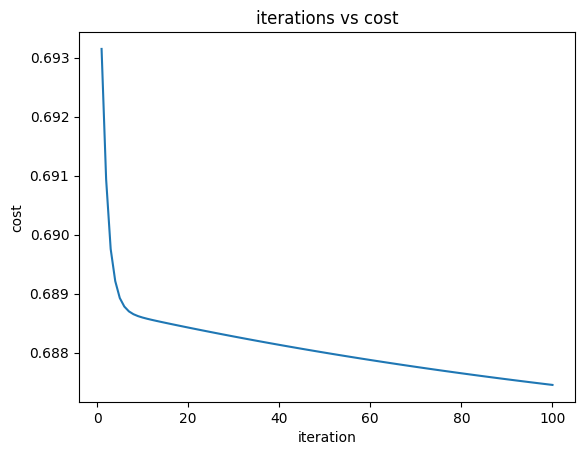

In [111]:
x = np.arange(1,len(cost_hist)+1)
y = cost_hist

plt.plot(x,y)

plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("iterations vs cost")